In [59]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [60]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [61]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [62]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [63]:
import torch
from src.utils.dataset import classical_split_awa2_features
import numpy as np

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni


In [64]:
from src.utils.box import compute_concept_implications
concept_implications = compute_concept_implications(y_train, class_concept_matrix)
concept_implications = torch.clamp(concept_implications, min=0.0, max=1.0)

In [65]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [66]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [67]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box_empirical
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=concept_implications.shape[0], dim=2)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

In [68]:
box_model = train_box_empirical(
    box_model, 
    concept_implications, 
    optimizer, 
    criterion,
    epochs=50,
)

Epoch 1/50 | Loss: 0.6564
Epoch 10/50 | Loss: 0.5132
Epoch 20/50 | Loss: 0.5007
Epoch 30/50 | Loss: 0.4875
Epoch 40/50 | Loss: 0.4866
Epoch 50/50 | Loss: 0.4839
Addestramento completato!


### Visualization

In [69]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

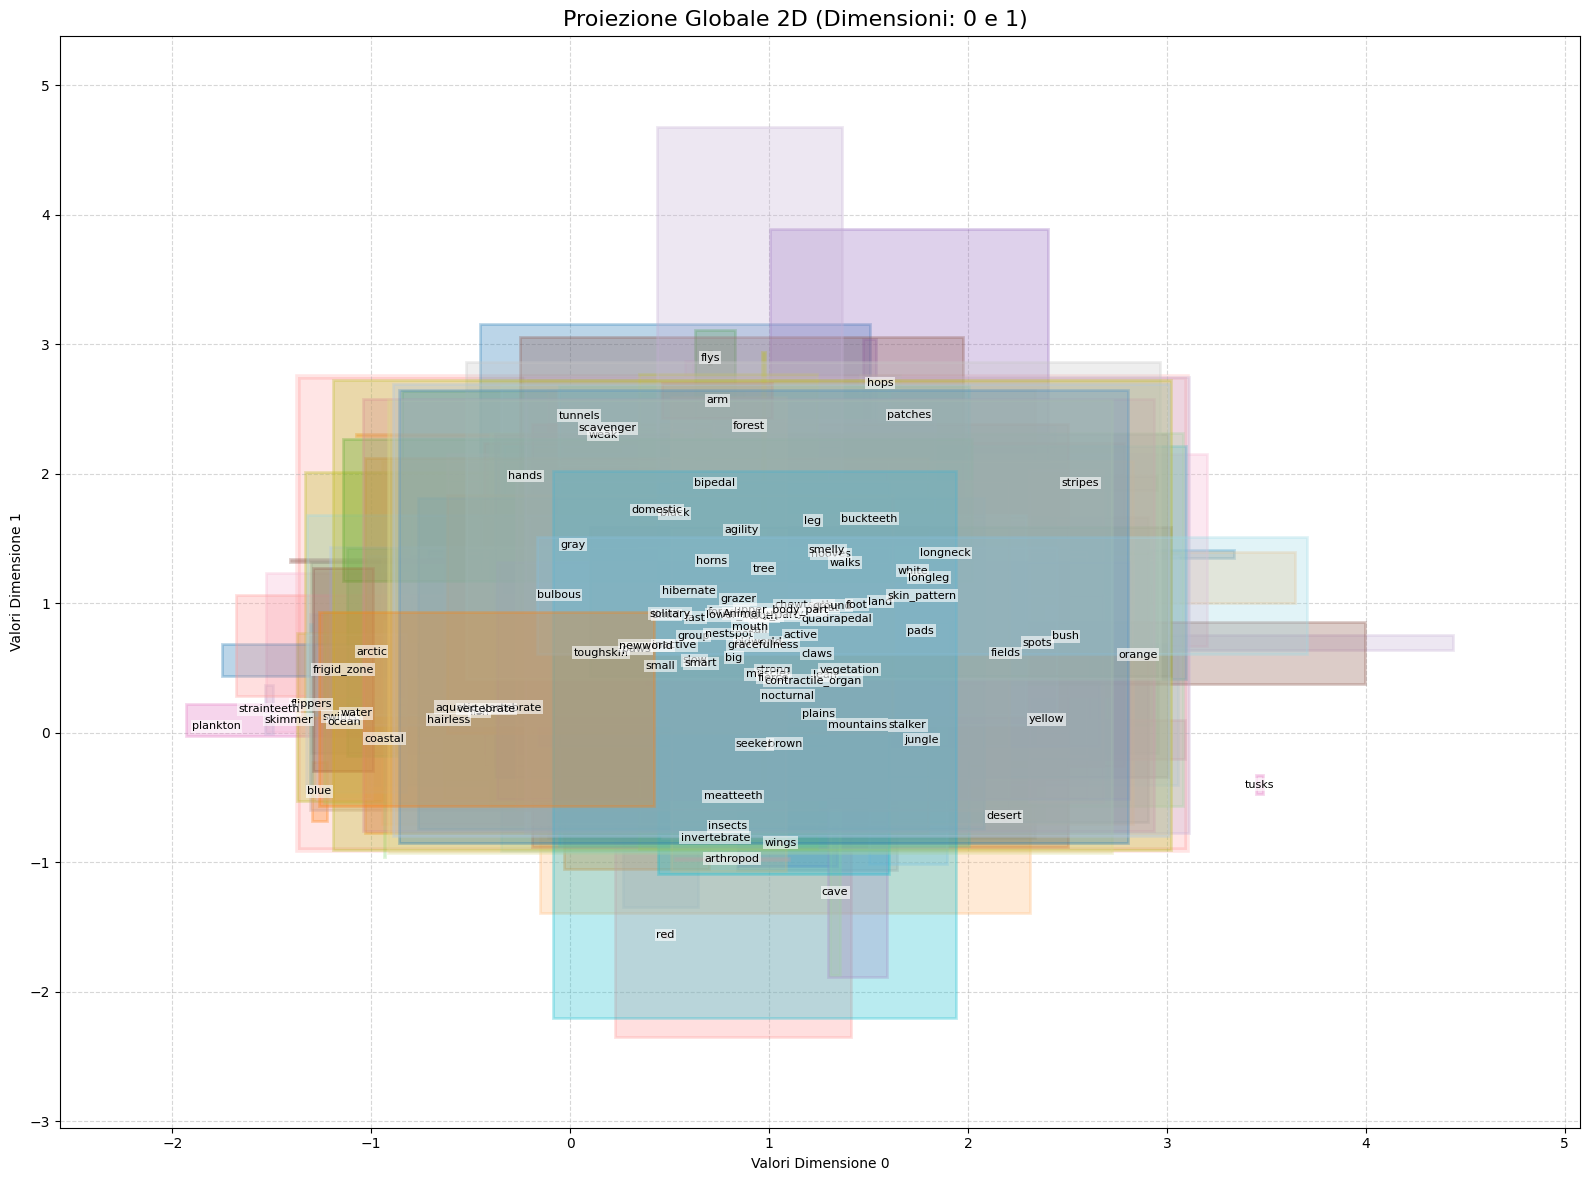

In [70]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

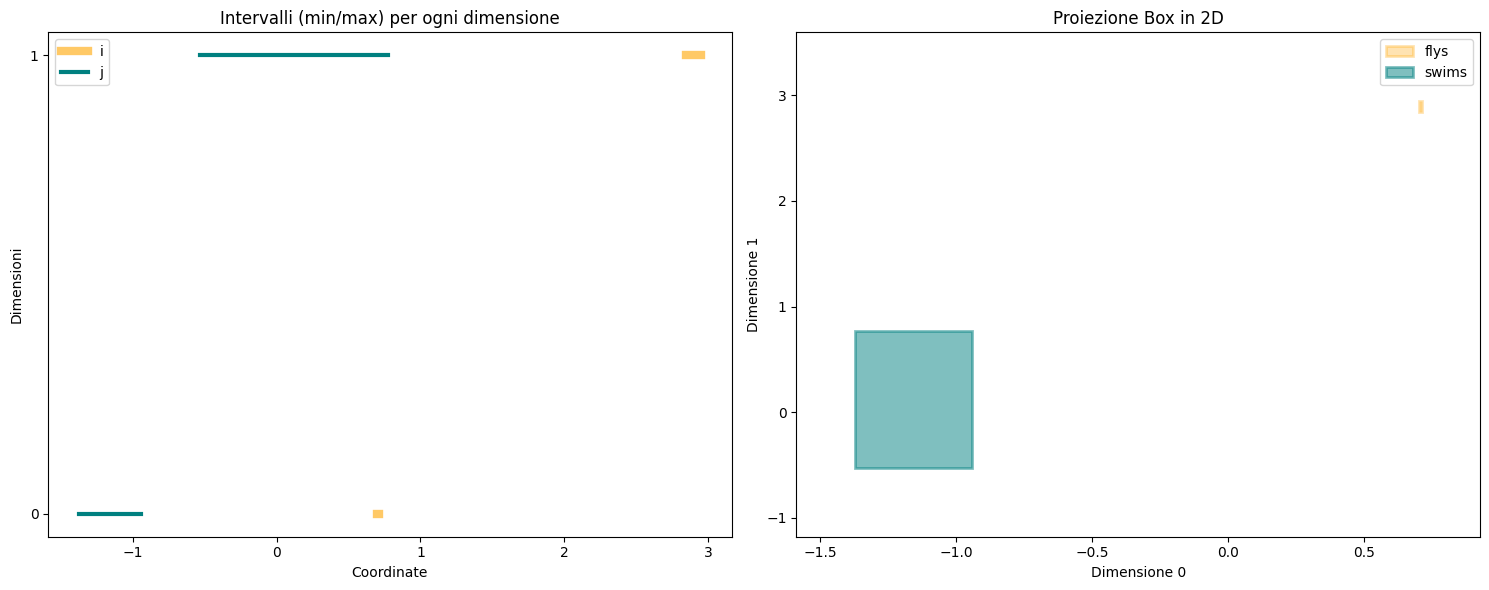

In [71]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "flys", "swims")

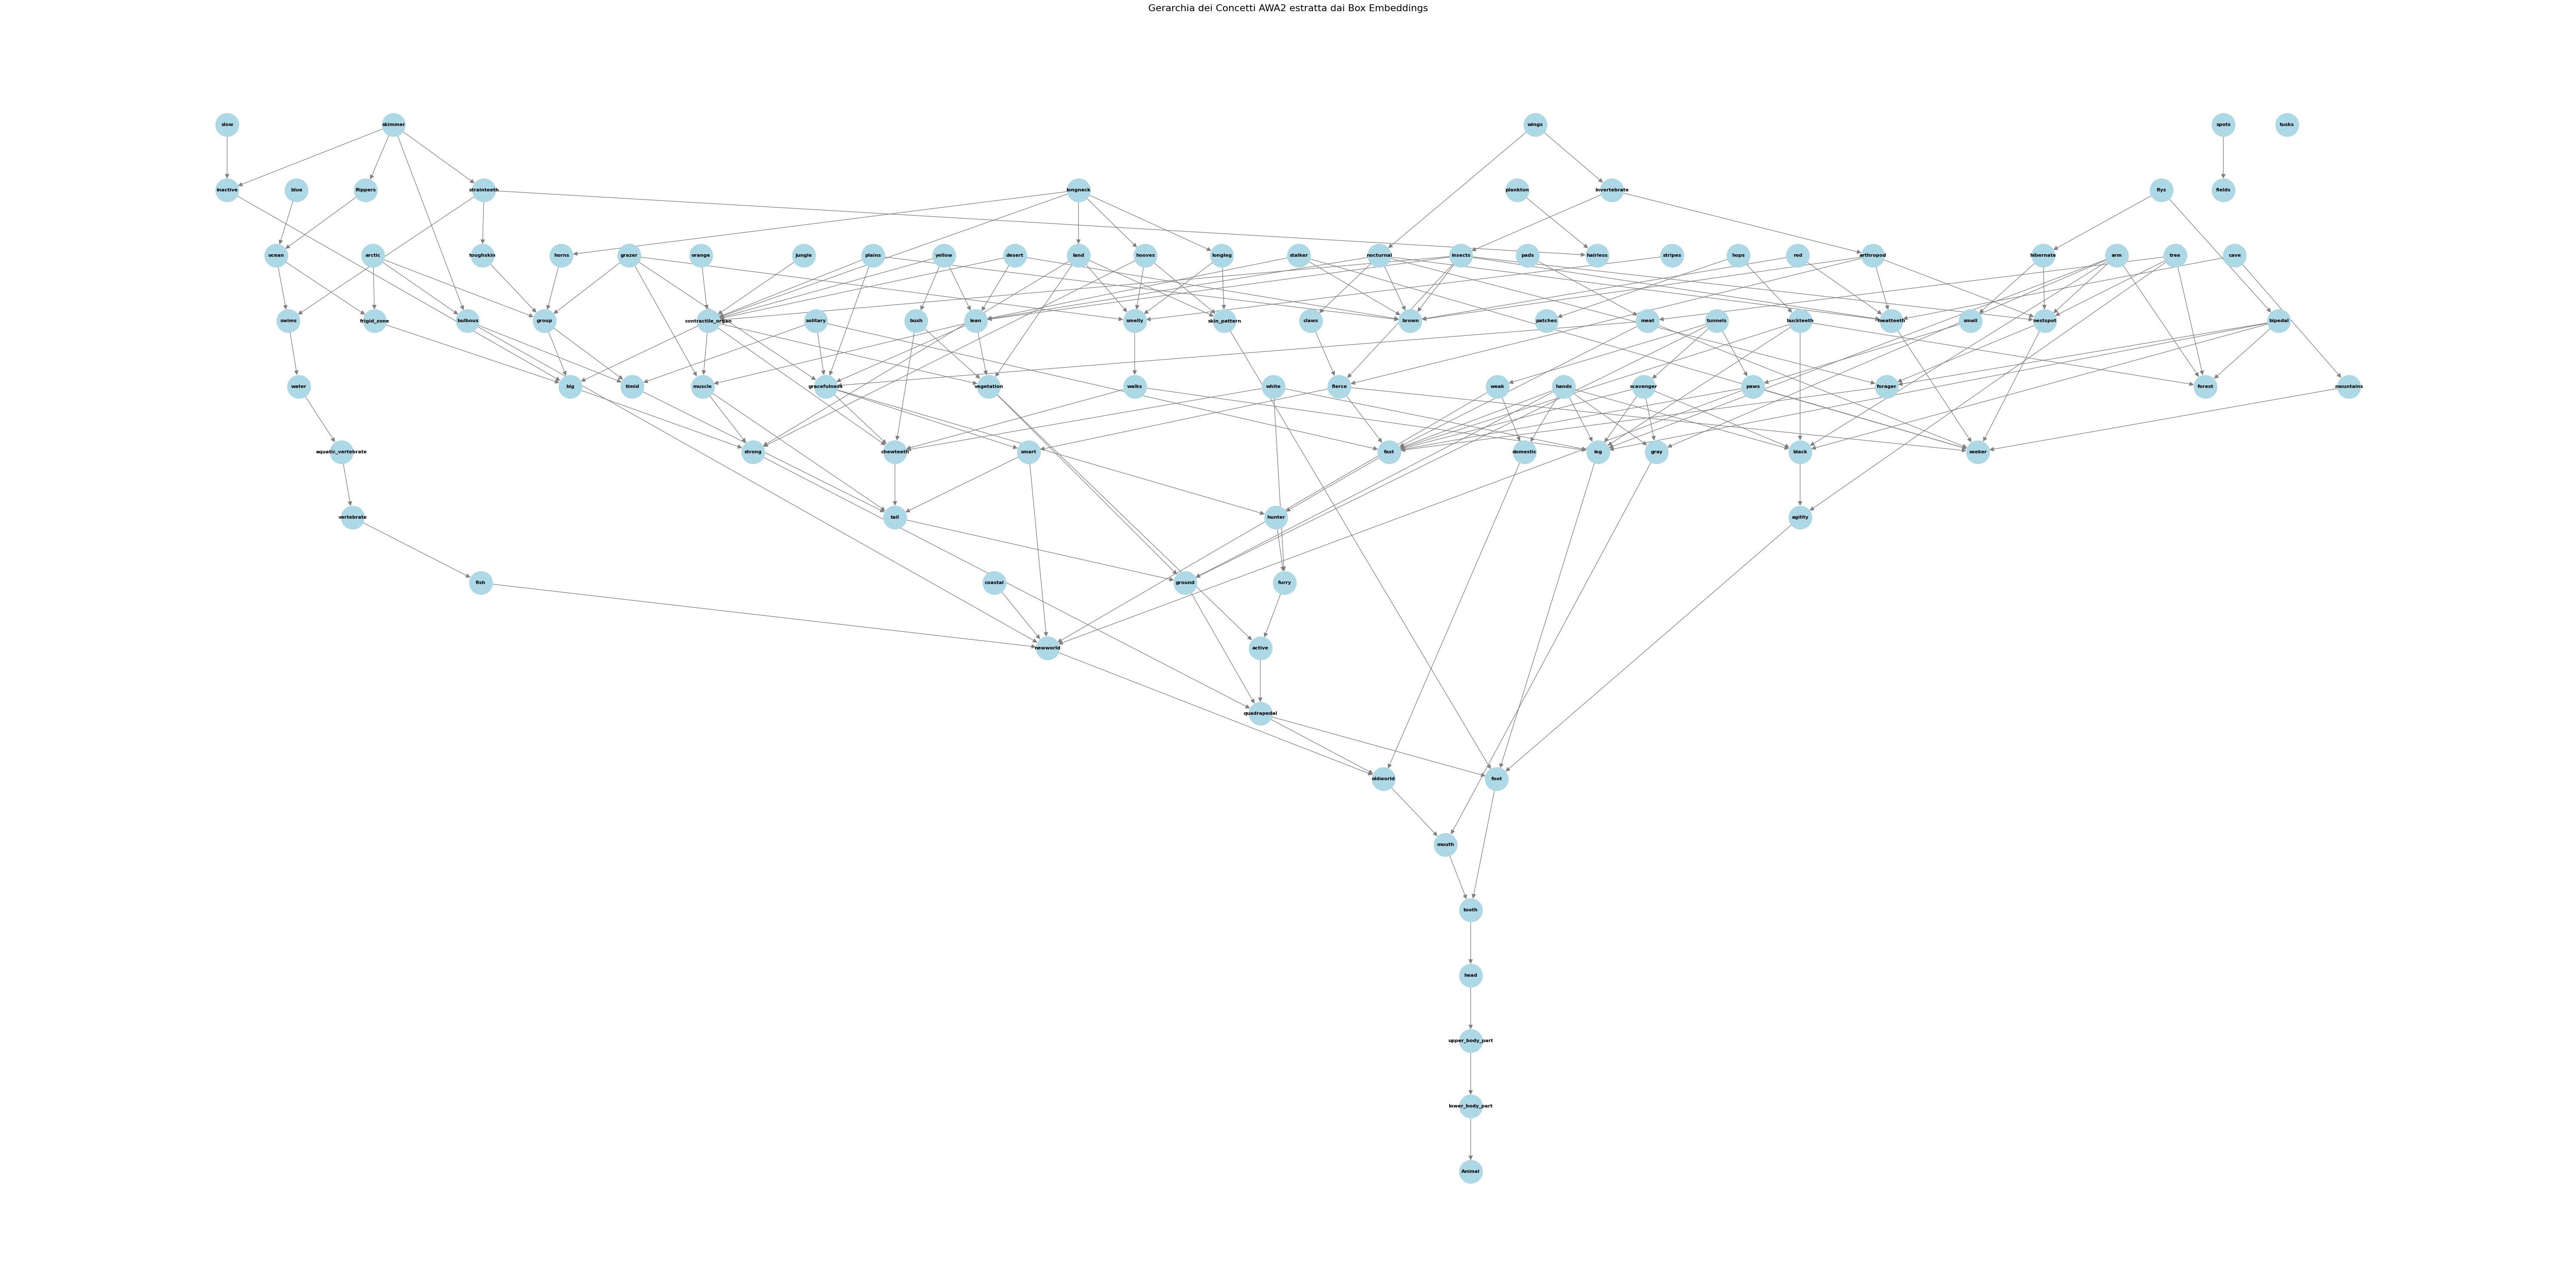

In [72]:
from src.utils.box import extract_hierarchy
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout

plt.figure(figsize=(60, 30))


hierarchy_graph = extract_hierarchy(box_model, num_concepts=len(concepts), concept_names=concepts)
pos = pydot_layout(hierarchy_graph, prog="dot")

nx.draw_networkx(
     hierarchy_graph, 
     labels=nx.get_node_attributes(hierarchy_graph, 'label'),
     node_size=1500, 
     node_color="lightblue", 
     font_size=8,
     pos=pos,
     font_weight="bold",
     edge_color="gray",
     arrows=True,
     arrowsize=15,       # Frecce ben visibili per indicare la direzione
     arrowstyle="-|>"
)
plt.title("Gerarchia dei Concetti AWA2 estratta dai Box Embeddings", fontsize=16)
plt.axis("off") # Rimuove il bordo e le coordinate dal grafico
plt.tight_layout()
plt.show()

### Save boxes

In [73]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [81]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [82]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [83]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [84]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Using device: cpu


In [85]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

### CBM with boxes

#### Train

In [86]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/5 | TRAIN: Loss=0.155, Acc=98.2% | VAL: Loss=0.006, Acc=100.0%
Epoca   3/5 | TRAIN: Loss=0.003, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   4/5 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   5/5 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/5 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Addestramento completato.


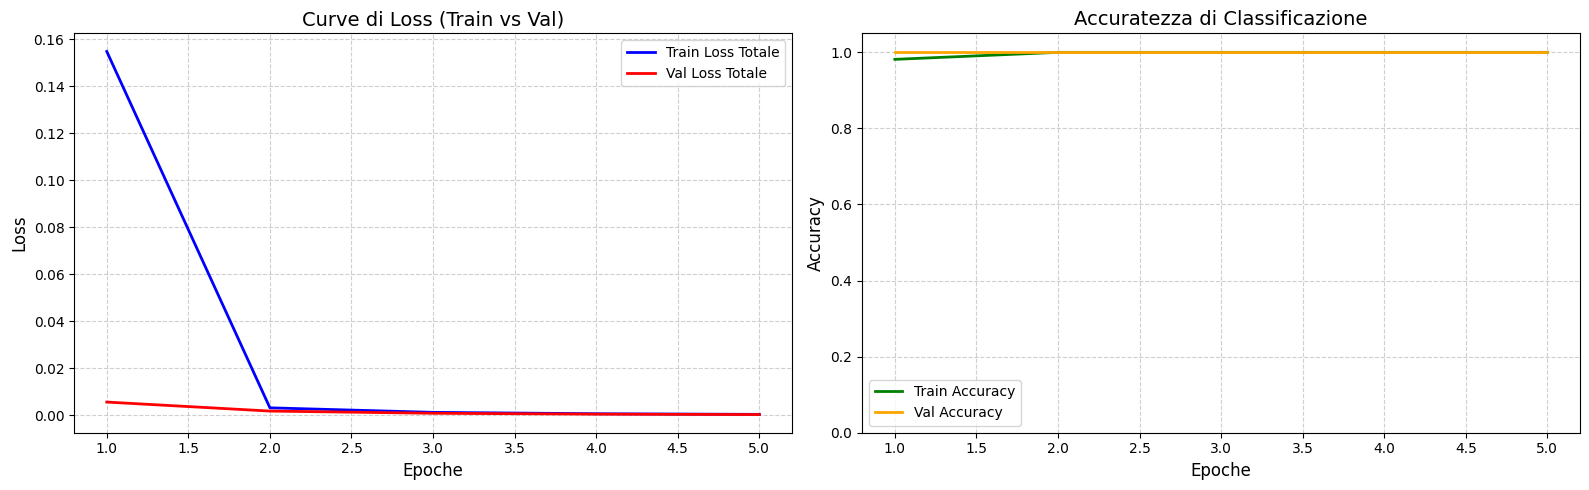

In [87]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [88]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


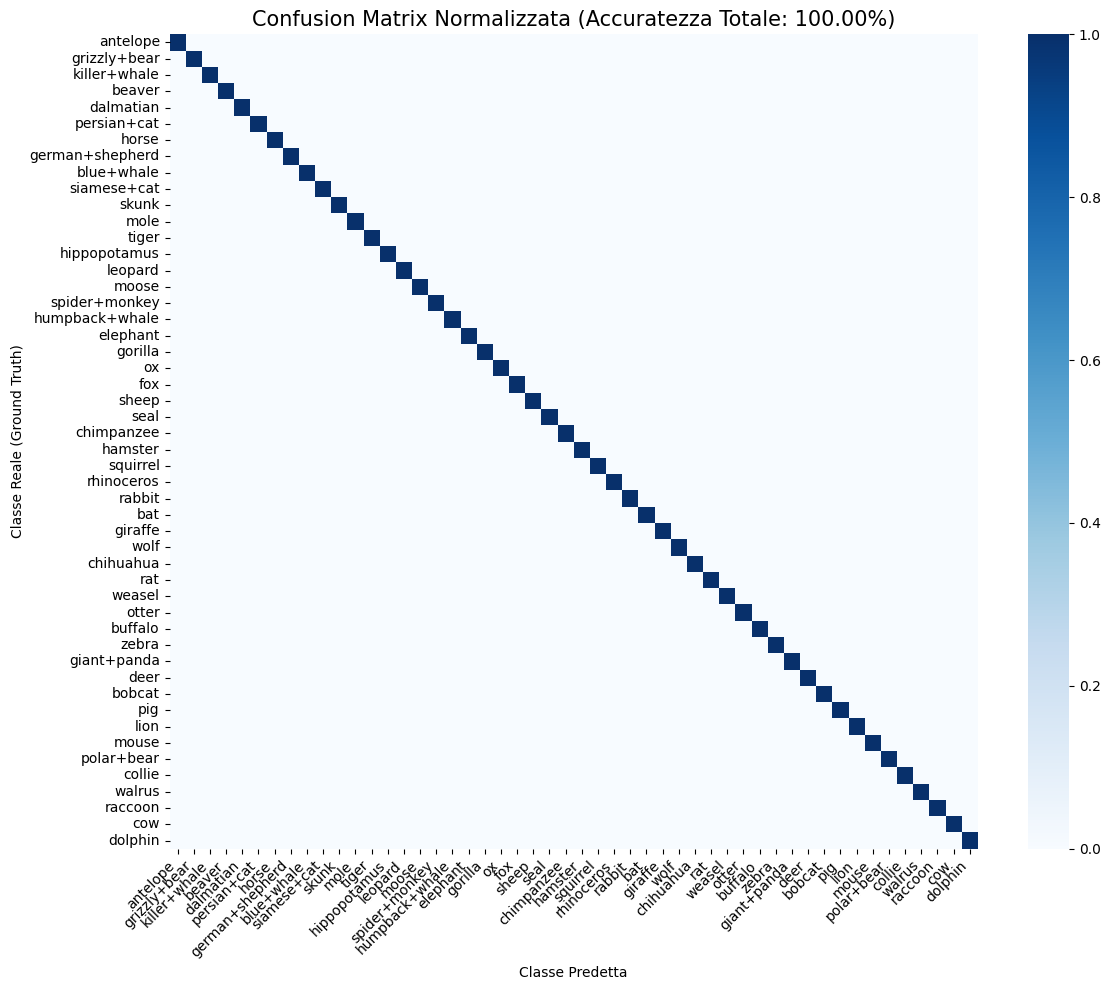


Analisi degli Errori Principali:


In [89]:
plot_test_results(accuracy, preds, labels, class_names=classes)

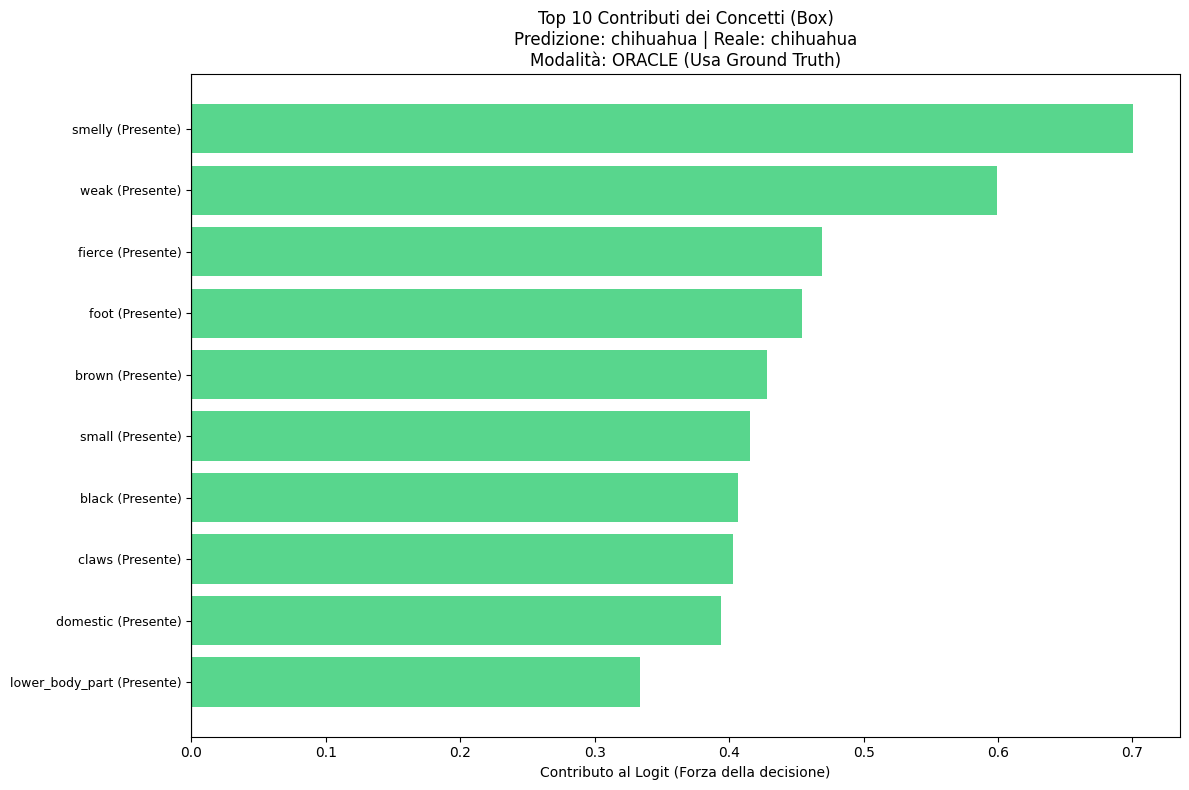

True

In [90]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [91]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/5 | TRAIN: Loss=0.017, Acc=99.7% | VAL: Loss=0.000, Acc=100.0%
Epoca   3/5 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   4/5 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/5 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/5 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Addestramento completato.


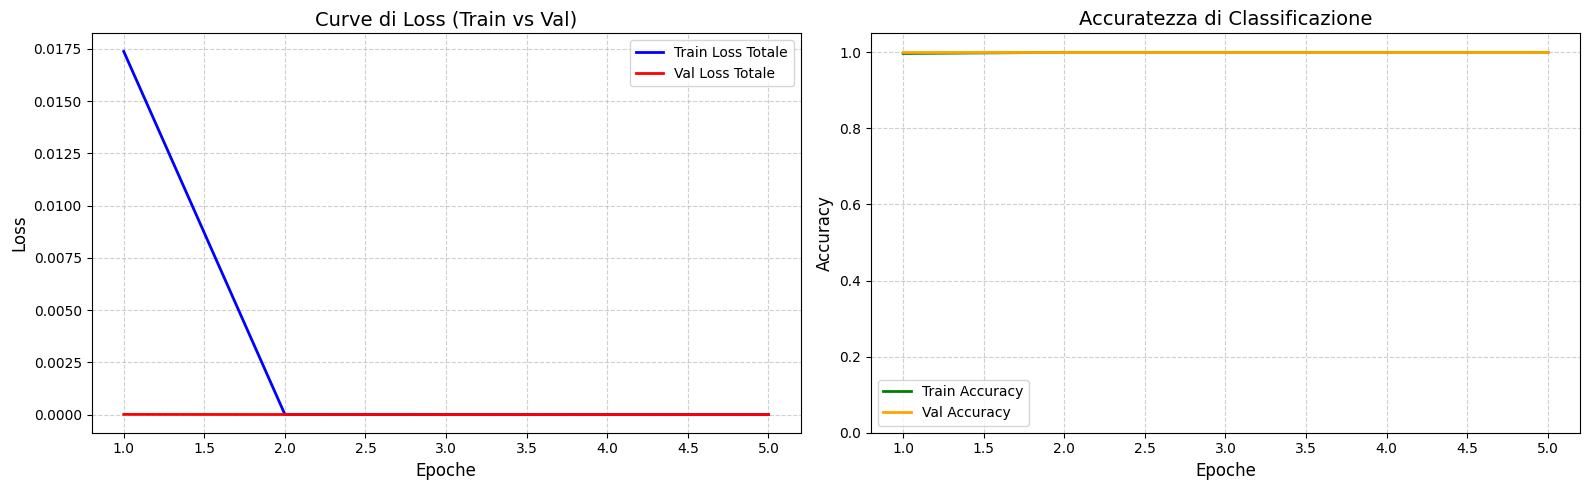

In [92]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [93]:
cp_accuracy, cp_preds, cp_labels, _, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


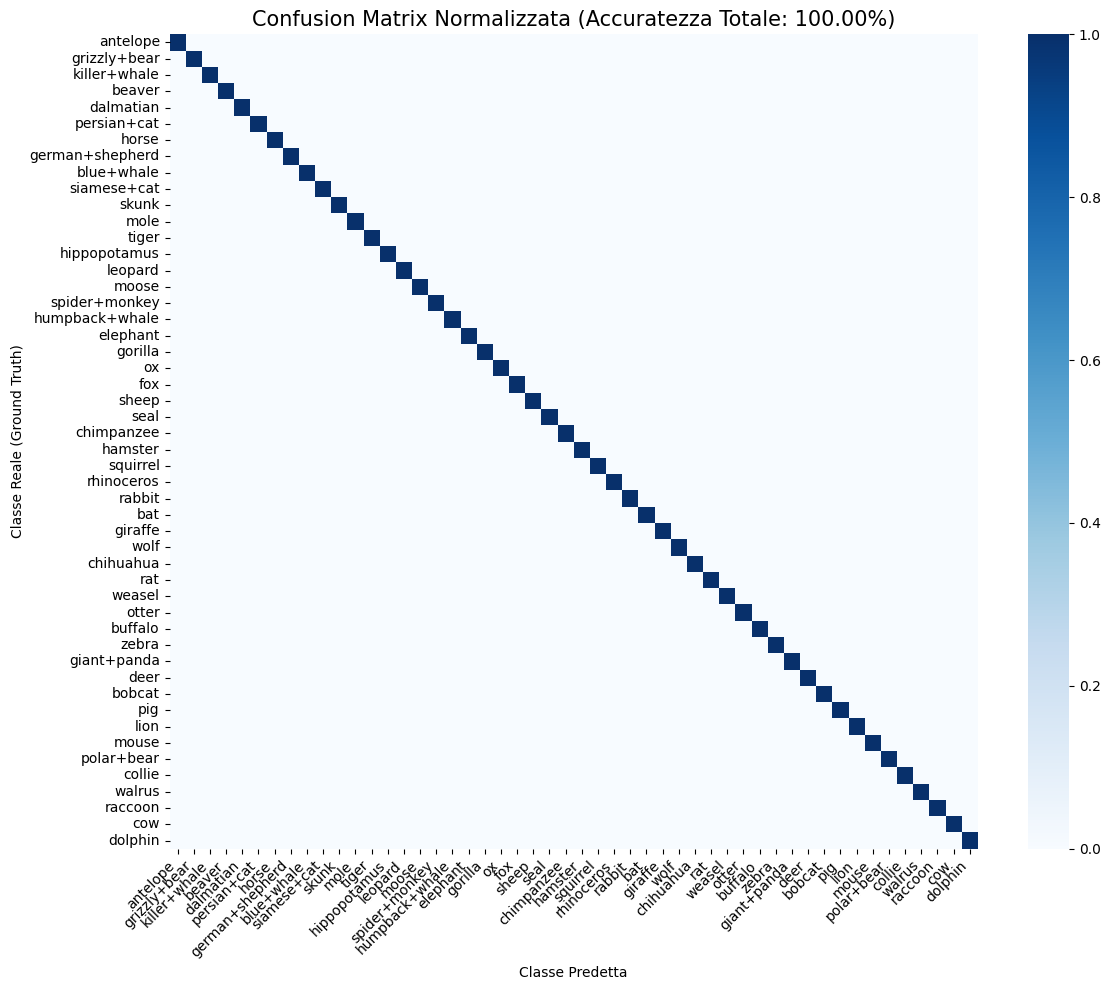


Analisi degli Errori Principali:


In [94]:
plot_test_results(accuracy, preds, labels, class_names=classes)

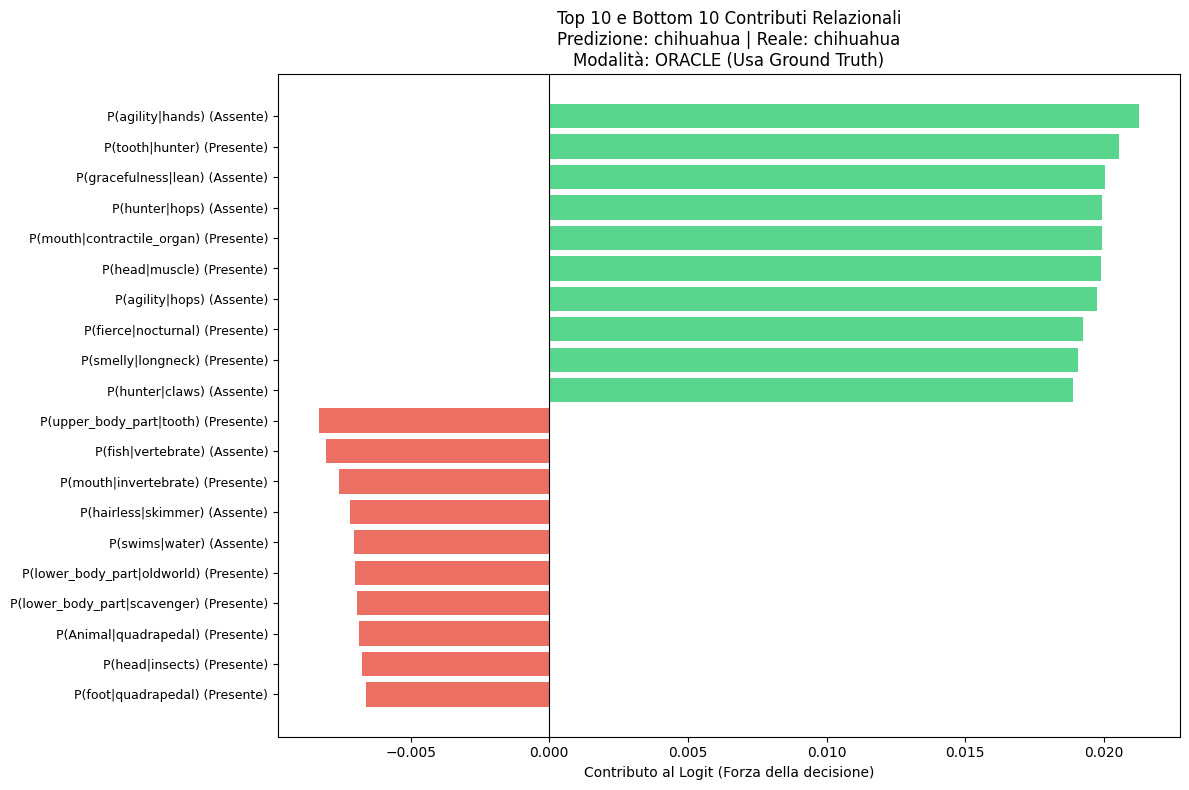

True

In [95]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [96]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/5 | TRAIN: Loss=0.718, Acc=94.0% | VAL: Loss=0.082, Acc=100.0%
Epoca   3/5 | TRAIN: Loss=0.044, Acc=100.0% | VAL: Loss=0.024, Acc=100.0%
Epoca   4/5 | TRAIN: Loss=0.016, Acc=100.0% | VAL: Loss=0.011, Acc=100.0%
Epoca   5/5 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.006, Acc=100.0%
Epoca   6/5 | TRAIN: Loss=0.005, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Addestramento completato.


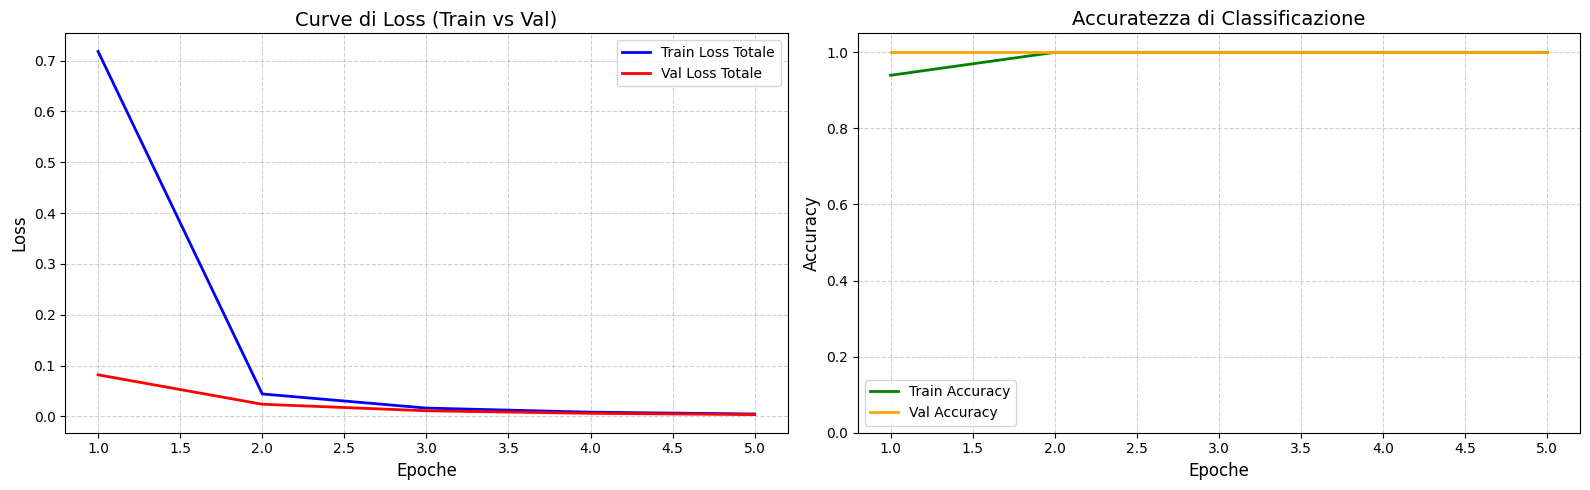

In [97]:
from src.utils.plot import plot_history
plot_history(c_history)

In [98]:
c_accuracy, c_preds, c_labels, _, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


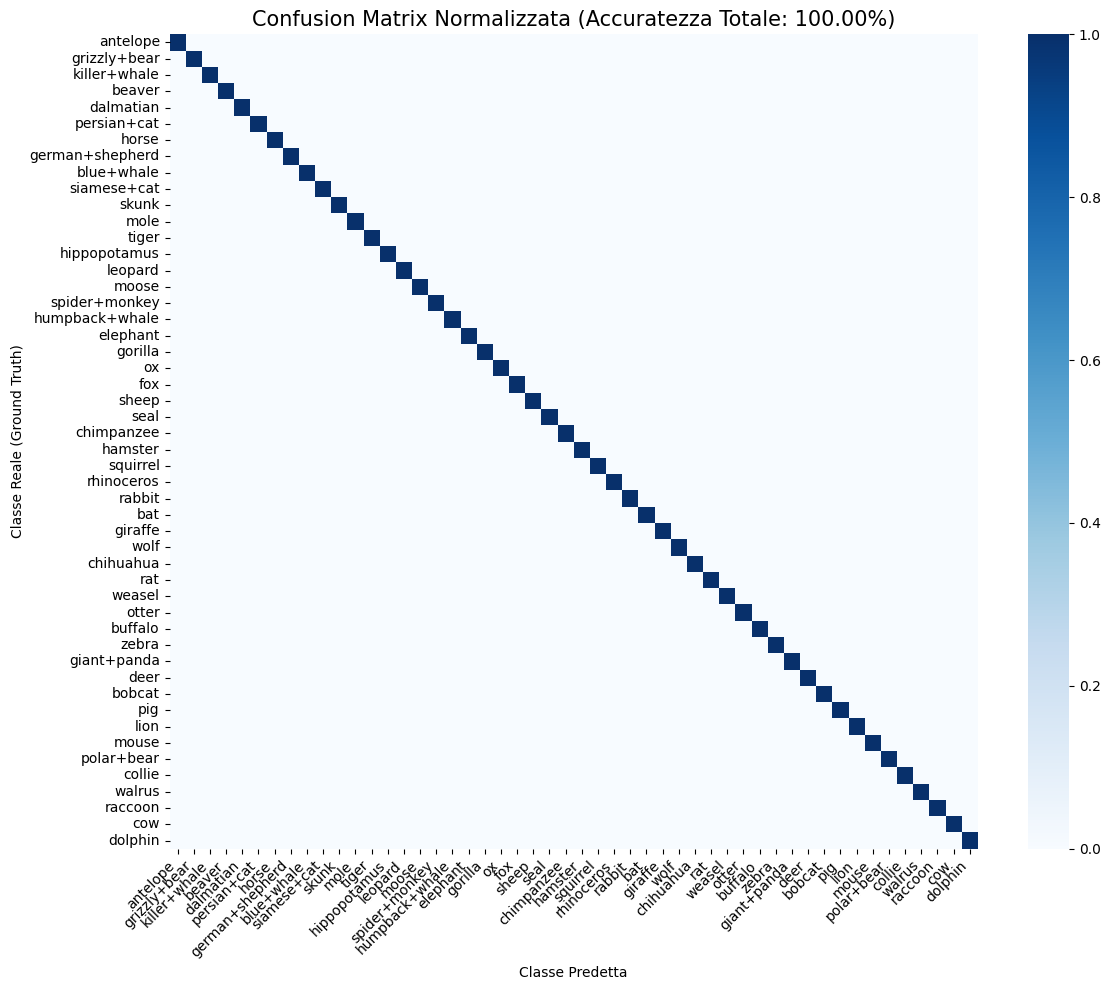


Analisi degli Errori Principali:


In [99]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

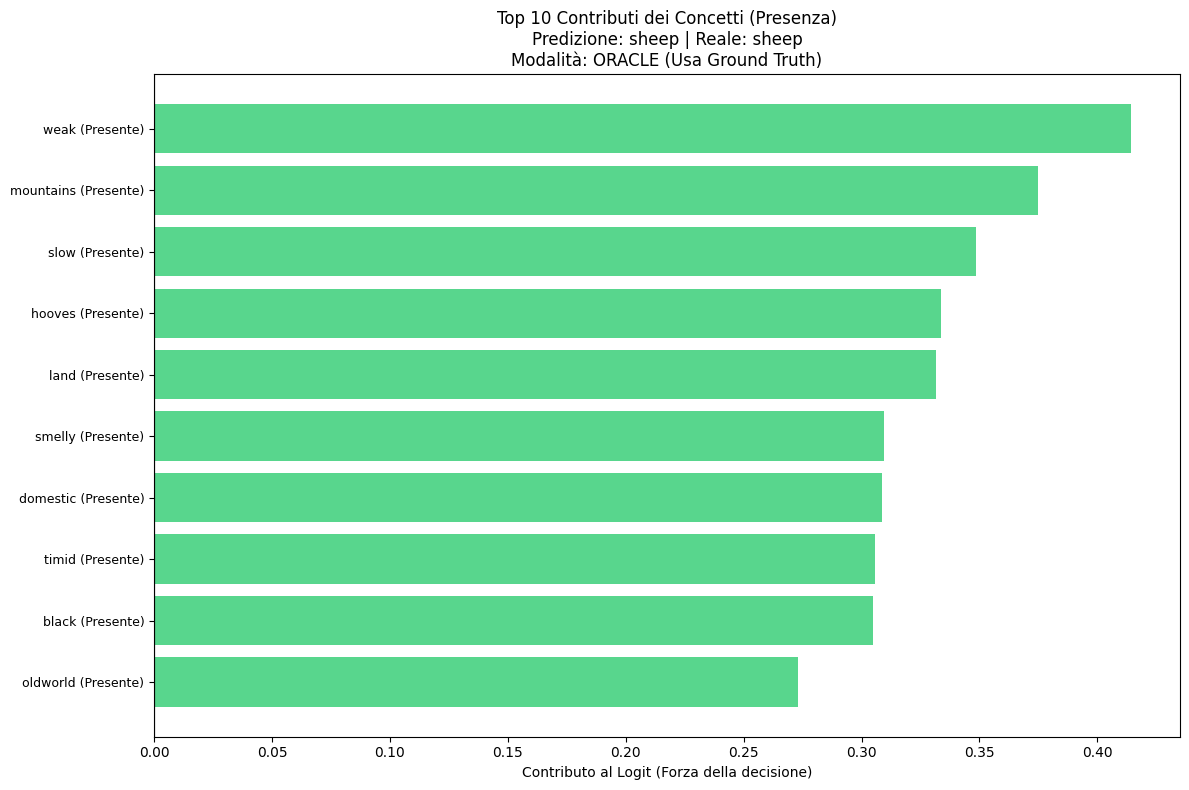

True

In [100]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Independent

### CONCEPT PREDICTOR

In [101]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [102]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 4.2291 | Acc: 95.1736 || Val Loss: 3.1379 | Val Acc: 96.3877
Loss: 2.7237 | Acc: 96.8892 || Val Loss: 2.7949 | Val Acc: 96.7602
Loss: 2.3711 | Acc: 97.2842 || Val Loss: 2.6868 | Val Acc: 96.8650
Loss: 2.1642 | Acc: 97.5151 || Val Loss: 2.6438 | Val Acc: 96.9456
Loss: 2.0194 | Acc: 97.6855 || Val Loss: 2.6110 | Val Acc: 96.9798


### BOXES

In [107]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 91.43%


In [104]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 14.16%


#### STATS 

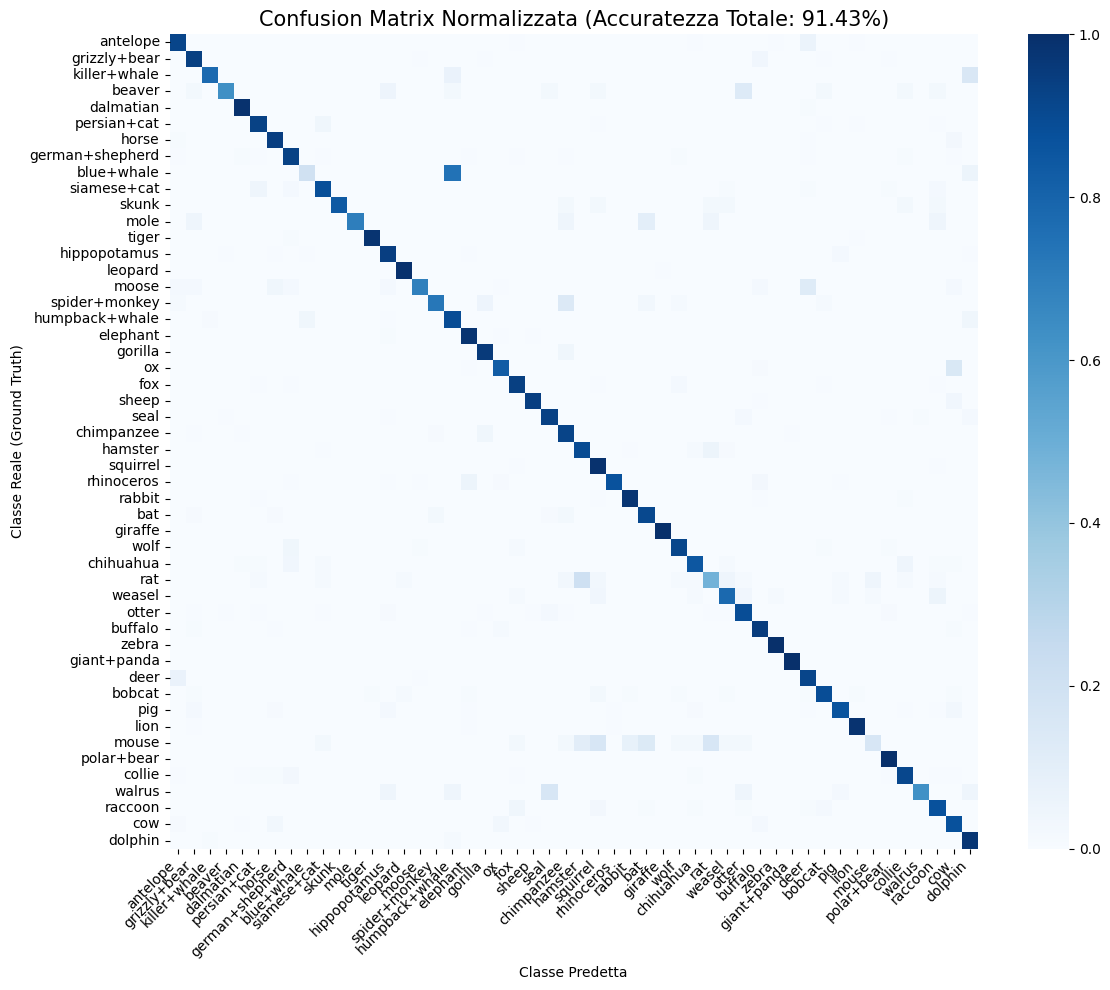


Analisi degli Errori Principali:
 - 26 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 22 volte: 'ox' è stato scambiato per 'cow'
 - 18 volte: 'moose' è stato scambiato per 'deer'
 - 18 volte: 'deer' è stato scambiato per 'antelope'
 - 13 volte: 'antelope' è stato scambiato per 'deer'


In [108]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

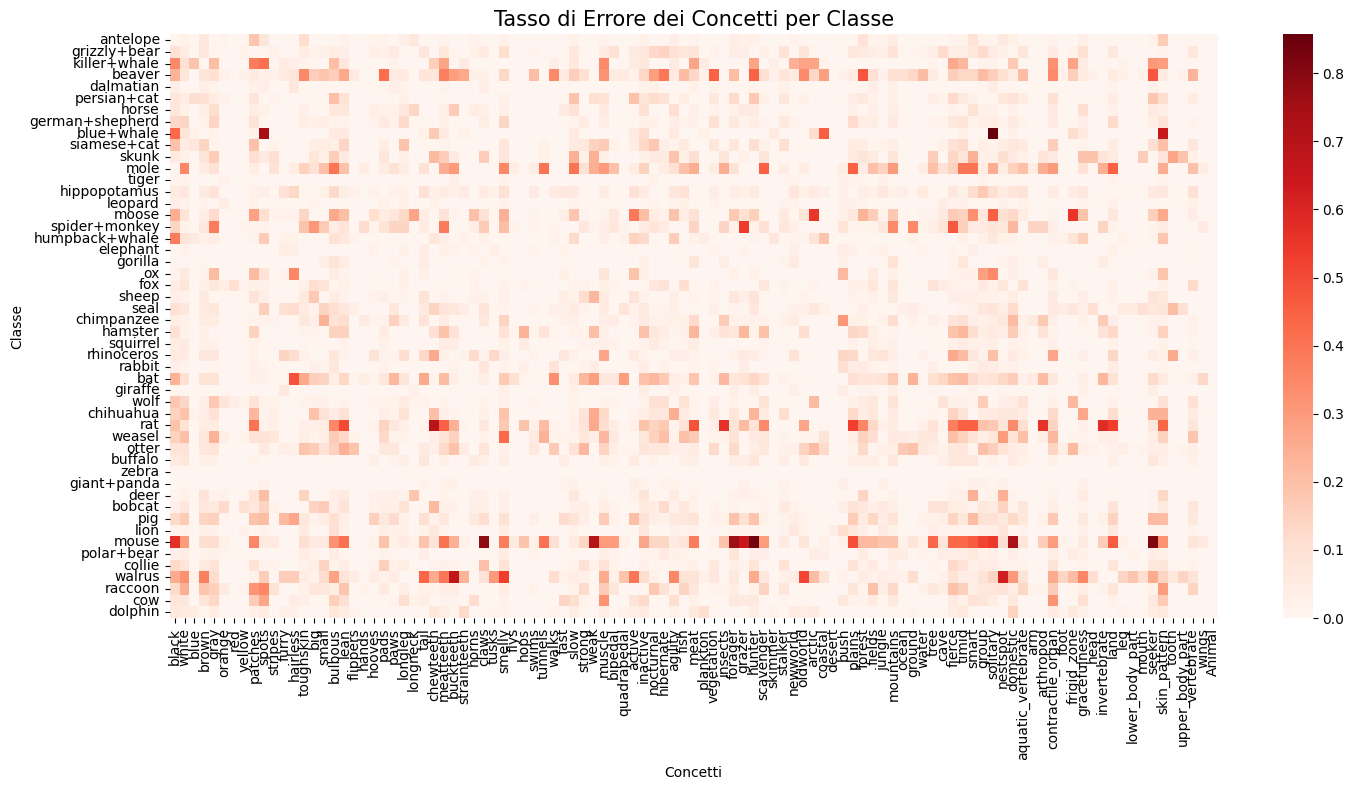

In [109]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [45]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'persian+cat'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [claws] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [smelly] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [slow] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [weak] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [inactive] Falso Positivo: D

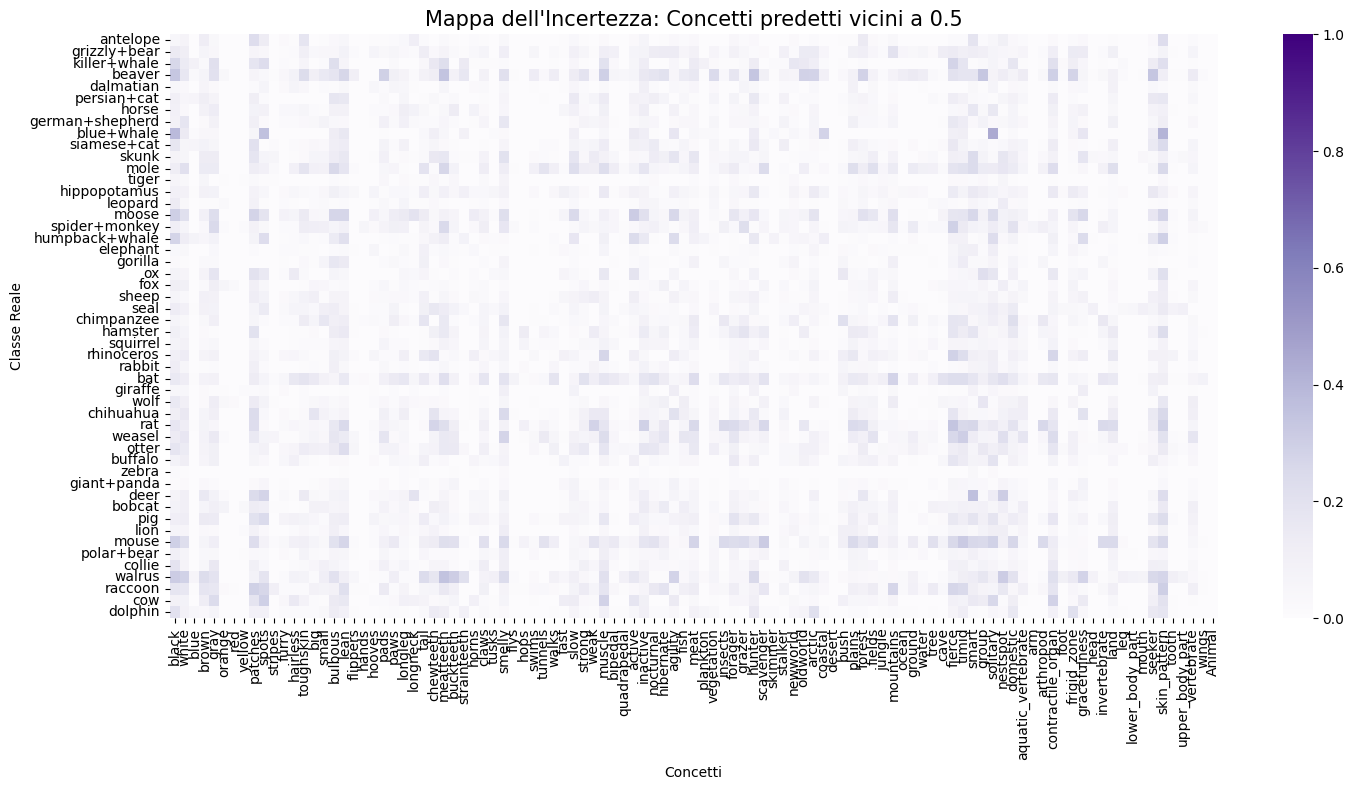

array([[4.98611294e-02, 7.03725889e-02, 2.82044039e-05, ...,
        1.61618404e-02, 7.26720373e-06, 7.98531108e-09],
       [1.47392347e-01, 1.18681200e-01, 7.22881596e-05, ...,
        6.25932589e-02, 1.20534614e-05, 0.00000000e+00],
       [2.58852392e-01, 1.40755877e-01, 9.21420753e-02, ...,
        1.13767814e-02, 1.10509063e-04, 8.22133028e-09],
       ...,
       [1.83416367e-01, 1.67757124e-01, 1.45865036e-02, ...,
        1.13076545e-01, 8.57990421e-03, 2.33743713e-09],
       [9.20890942e-02, 8.35891888e-02, 3.33955031e-05, ...,
        1.16110956e-02, 6.35857020e-07, 8.89621532e-09],
       [2.04132825e-01, 9.30628479e-02, 4.79452945e-02, ...,
        7.79025396e-03, 4.64908342e-04, 1.51376884e-08]])

In [46]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION


--- Valutazione con k=0 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.88%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.88%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.14%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.14%

--- Valutazione con k=1 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.02%
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.71%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.27%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.76%

--- Valutazione con k=2 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.30%
Inizio valutazione sul Test Set...

Accuratezza Totale: 93.40%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.57%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.40%

--- Valutazione con k=3 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 92.54%
Inizio valutazione su

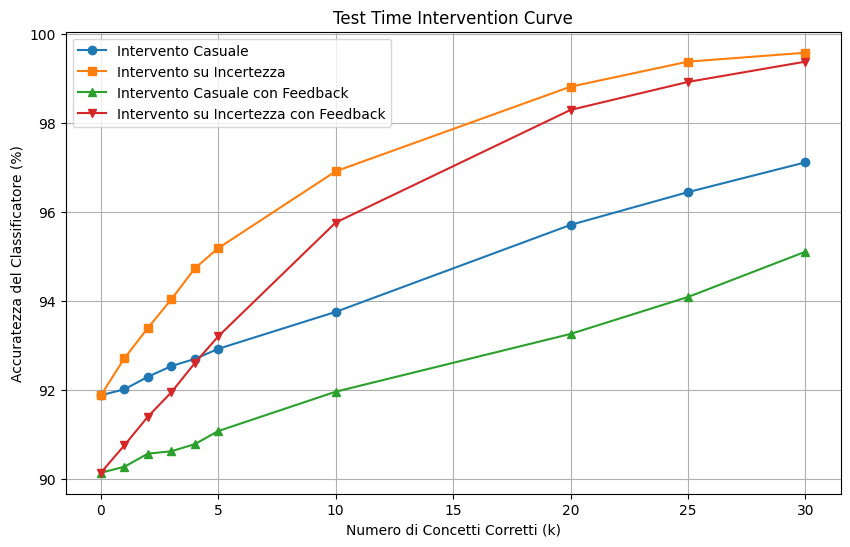

In [47]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX

In [112]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 80.50%


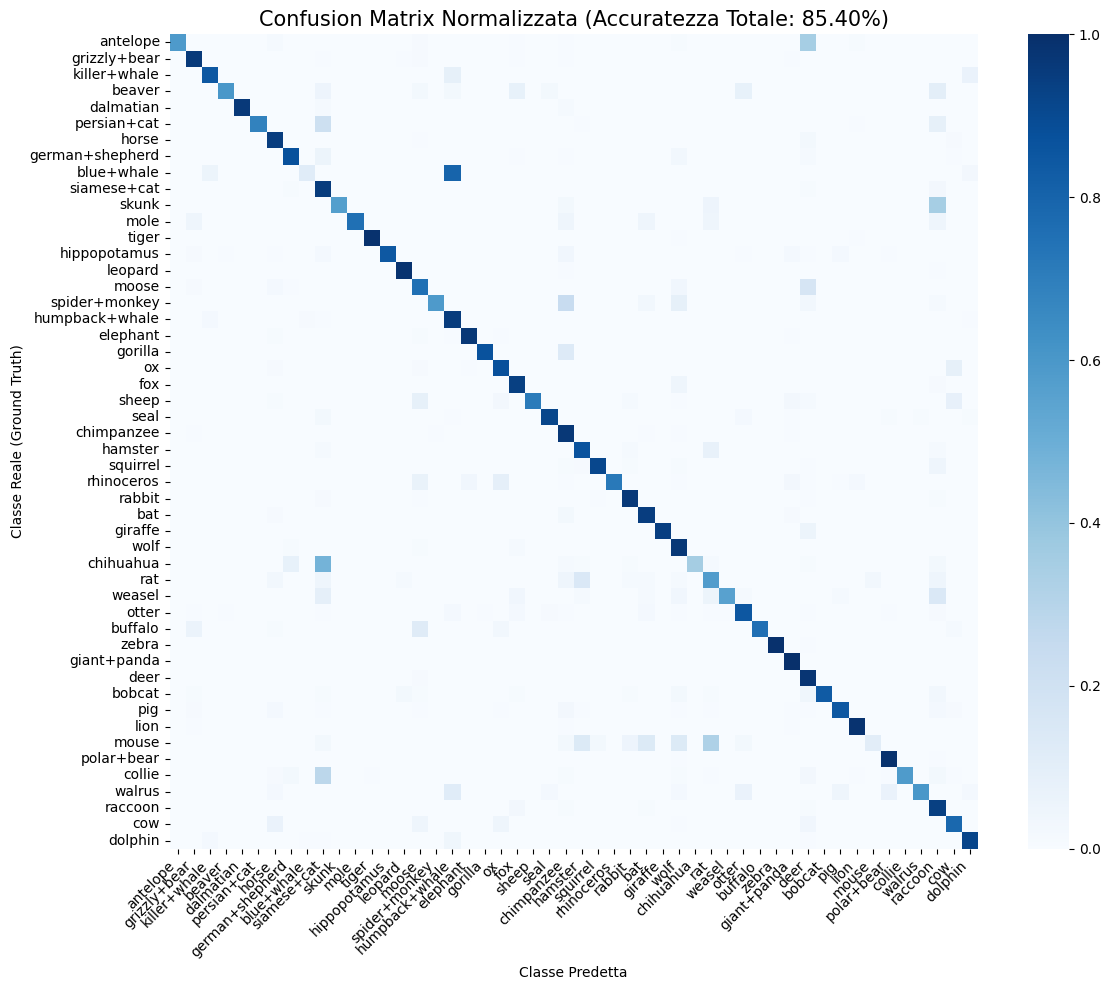


Analisi degli Errori Principali:
 - 73 volte: 'antelope' è stato scambiato per 'deer'
 - 58 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 54 volte: 'chihuahua' è stato scambiato per 'siamese+cat'
 - 32 volte: 'persian+cat' è stato scambiato per 'siamese+cat'
 - 28 volte: 'blue+whale' è stato scambiato per 'humpback+whale'


In [56]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True,
     alpha=0.95
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 90.74%


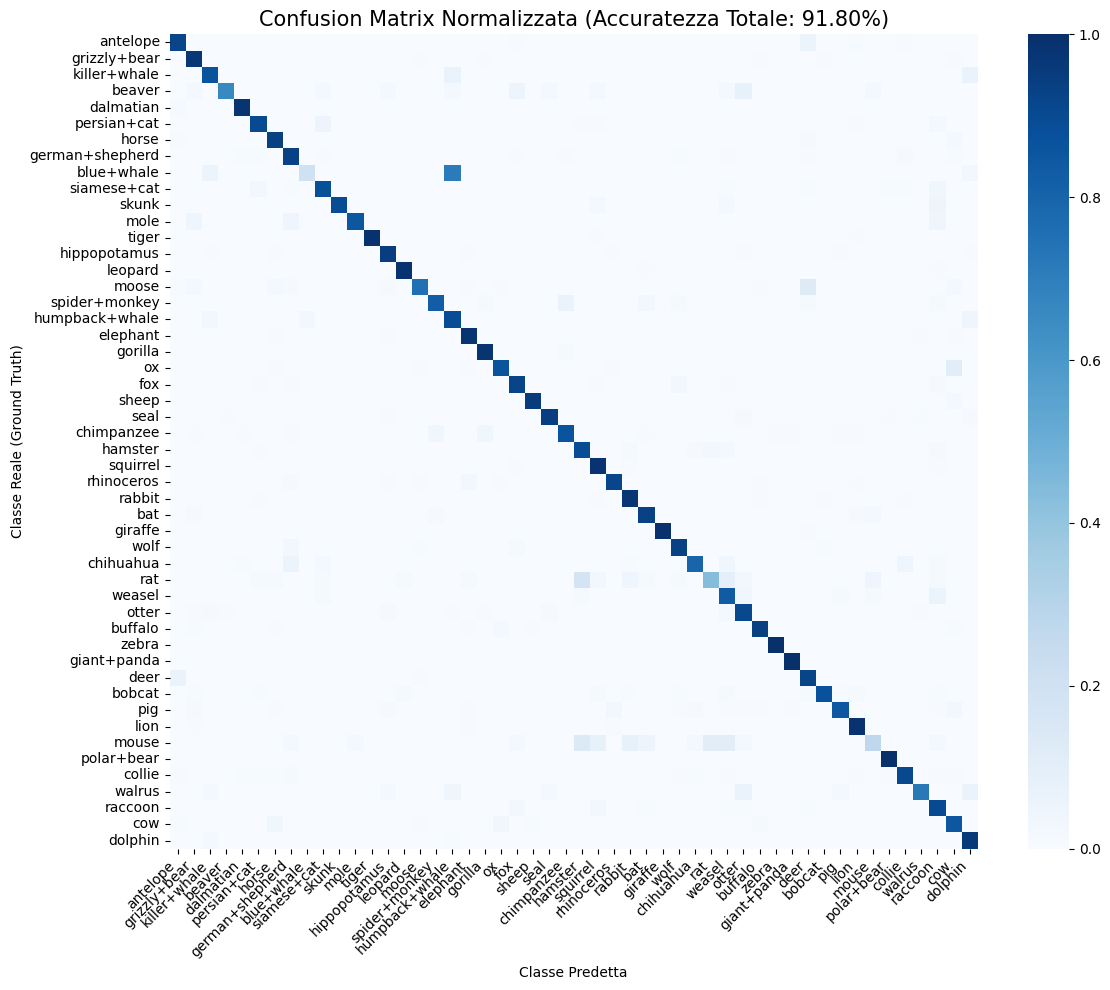


Analisi degli Errori Principali:
 - 25 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 18 volte: 'moose' è stato scambiato per 'deer'
 - 18 volte: 'deer' è stato scambiato per 'antelope'
 - 16 volte: 'ox' è stato scambiato per 'cow'
 - 13 volte: 'antelope' è stato scambiato per 'deer'


In [58]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM

In [120]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 91.28%


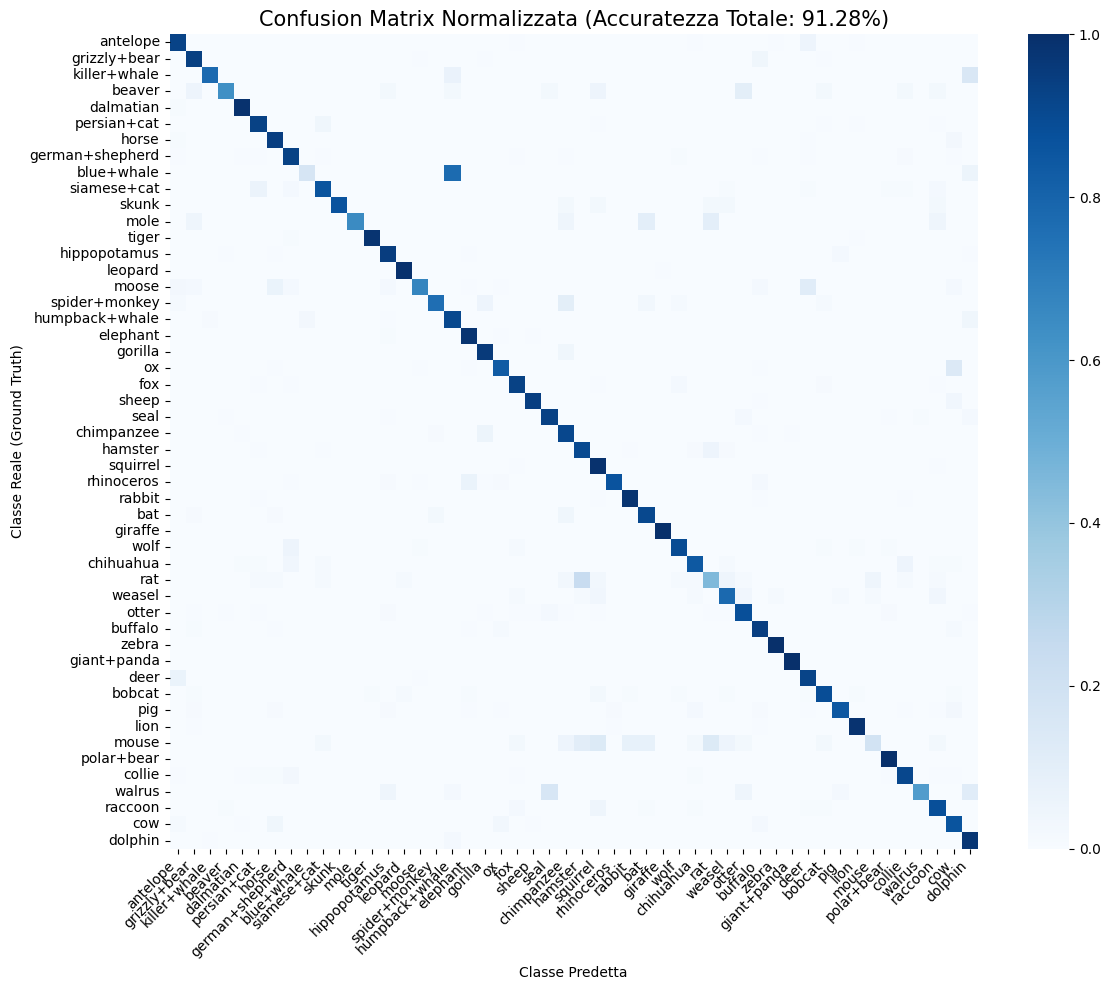


Analisi degli Errori Principali:
 - 27 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'
 - 17 volte: 'deer' è stato scambiato per 'antelope'
 - 16 volte: 'moose' è stato scambiato per 'deer'
 - 15 volte: 'rat' è stato scambiato per 'hamster'


In [122]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [128]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True,
     alpha=0.95
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 89.44%
